<a href="https://colab.research.google.com/github/Dripp234/day3AI/blob/main/DAY_3_FORCAST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Day             0
dtype: int64

Summary Statistics:
              Store                 Date  Weekly_Sales  Holiday_Flag  \
count  6435.000000                 6435  6.435000e+03   6435.000000   
mean     23.000000  2011-06-17 00:00:00  1.046965e+06      0.069930   
min       1.000000  2010-02-05 00:00:00  2.099862e+05      0.000000   
25%      12.000000  2010-10-08 00:00:00  5.533501e+05      0.000000   
50%      23.000000  2011-06-17 00:00:00  9.607460e+05      0.000000   
75%      34.000000  2012-02-24 00:00:00  1.420159e+06      0.000000   
max      45.000000  2012-10-26 00:00:00  3.818686e+06      1.000000   
std      12.988182                  NaN  5.643666e+05      0.255049   

       Temperature   Fuel_Price          CPI  Unemployment         Year  \
count  6435.000000  6435.000000  64

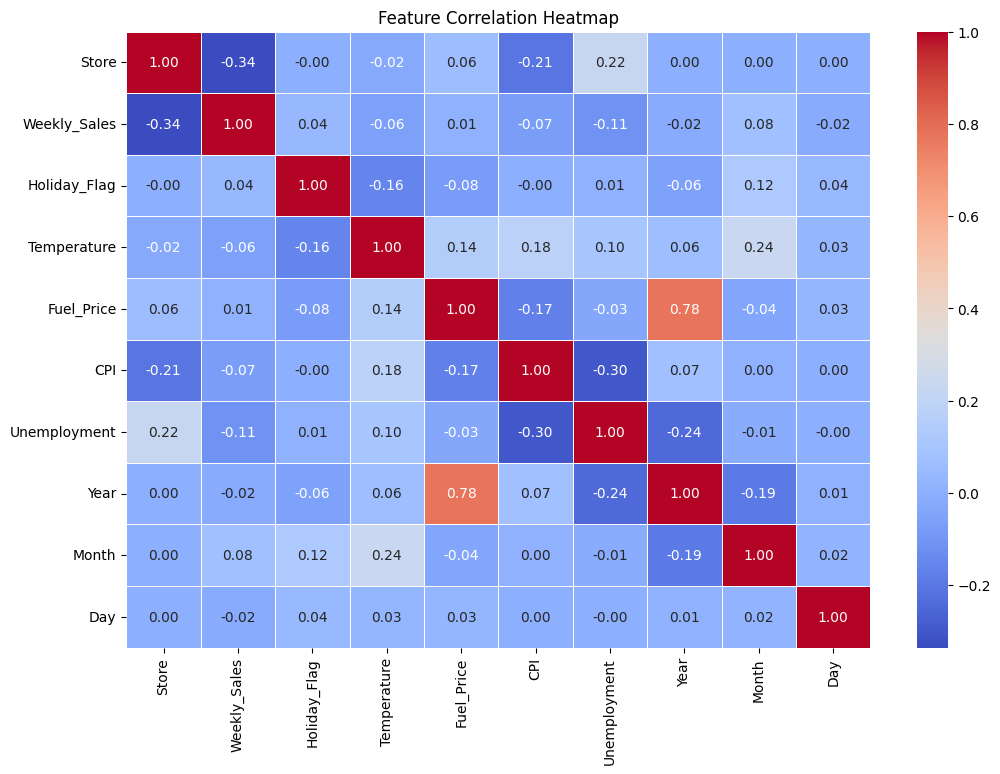

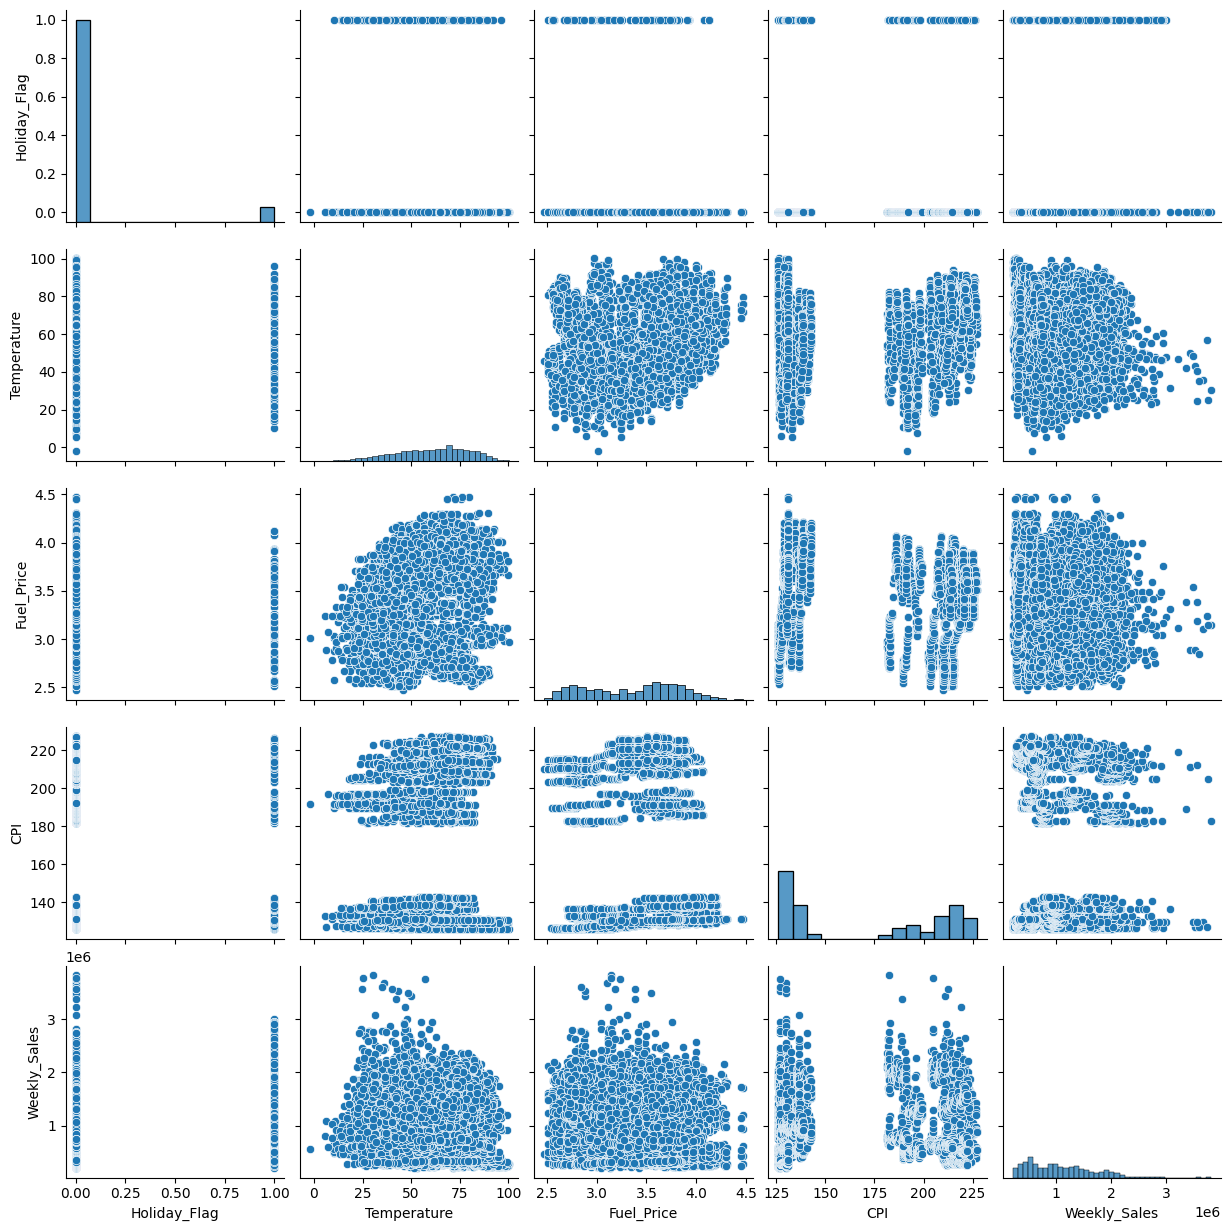

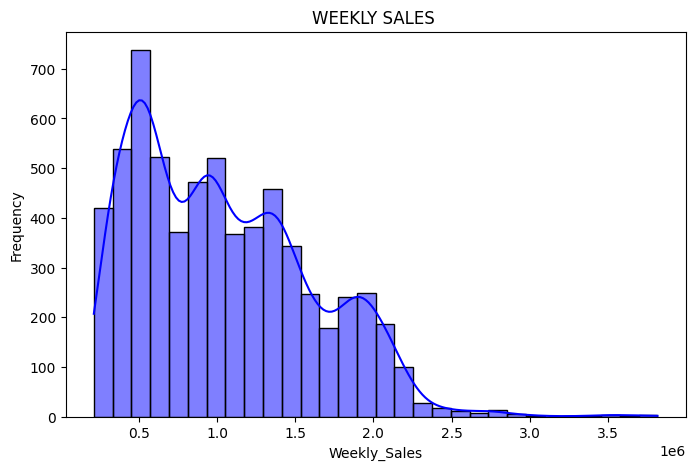

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
print("Missing Values:\n", df.isnull().sum())


print("\nSummary Statistics:\n", df.describe())

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# the annotation would show the correlation values for each pair of variables in your DataFrame.
#annot=True, you're asking the heatmap to display the actual numeric value inside each colored cell.
plt.title("Feature Correlation Heatmap")

plt.show()

sns.pairplot(df[['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI','Weekly_Sales']])
plt.show()

# Distribution of target variable (MEDV)
plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='blue')
plt.title("WEEKLY SALES ")
plt.xlabel("Weekly_Sales")
plt.ylabel("Frequency")
plt.show()


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
# Make sure Month and Year are included in your training features!
X = df[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year']]
y = df['Weekly_Sales']

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1564
RMSE: 521321.8139


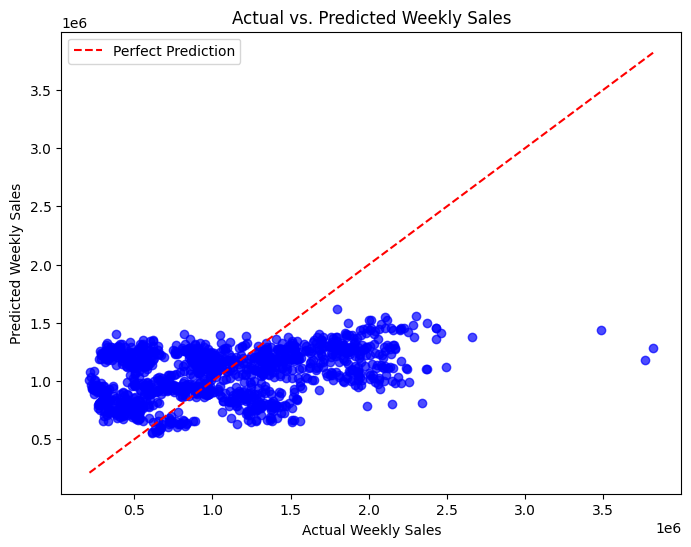

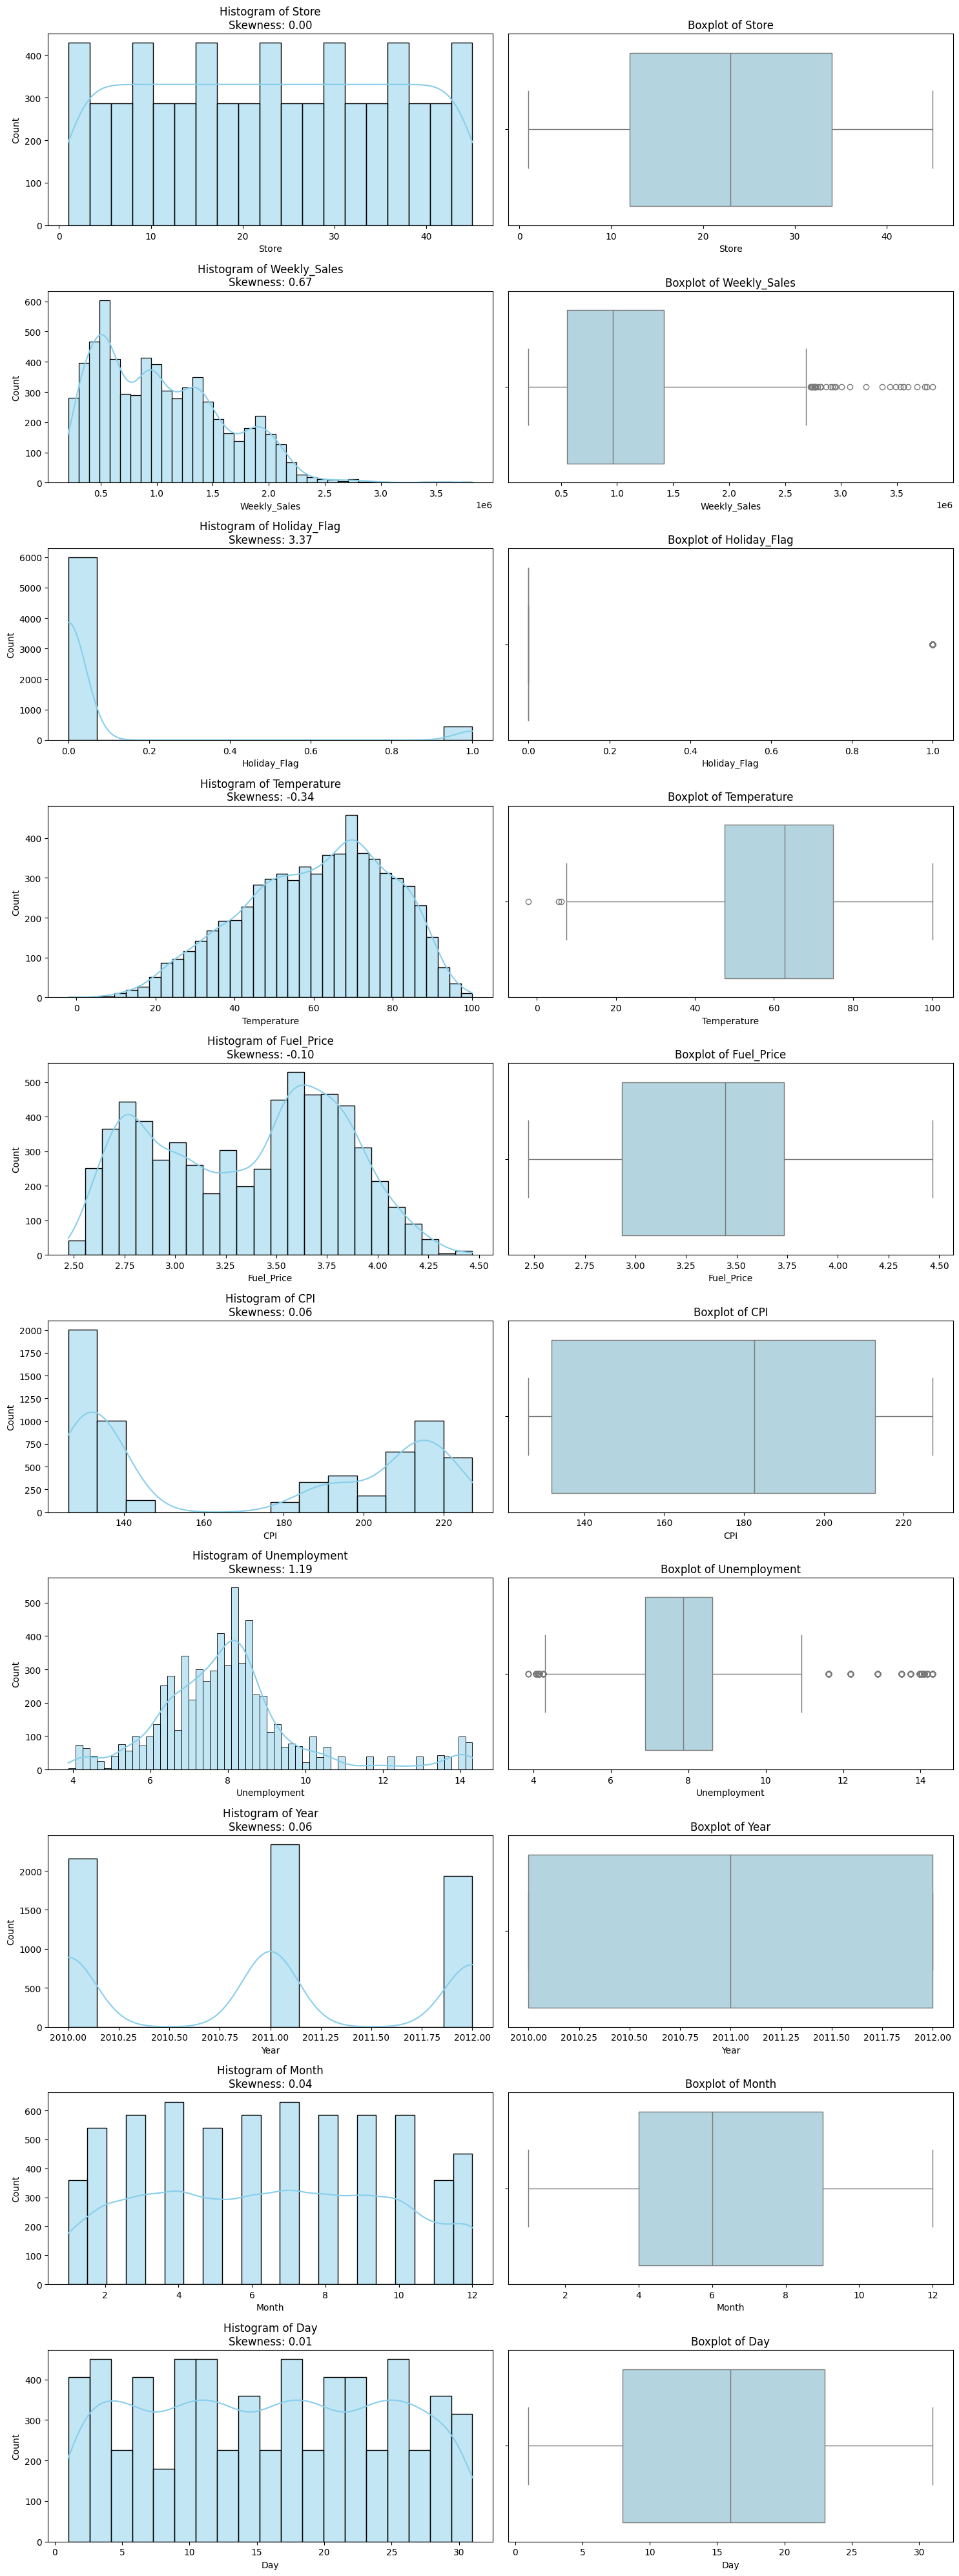

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# 1. Scatter plot of actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(x=y_test, y=y_pred, alpha=0.7, color='blue')
X = df[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year']]
y = df['Weekly_Sales']

# Dynamically draw the reference identity line based on data range
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Prediction")

plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs. Predicted Weekly Sales")  # Cleaned up title
plt.legend()
plt.show()


# 2. Calculate skewness for numeric columns only
skewness = df.skew(numeric_only=True)

# Filter out non-numeric columns (like Date) before plotting distributions
numeric_cols = df.select_dtypes(include=['number']).columns
num_cols = len(numeric_cols)

# Adjusted height based on actual numeric columns plotting
plt.figure(figsize=(15, num_cols * 4))

for i, col in enumerate(numeric_cols):
    # Histogram + KDE
    plt.subplot(num_cols, 2, 2 * i + 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Histogram of {col}\nSkewness: {skewness[col]:.2f}")

    # Boxplot
    plt.subplot(num_cols, 2, 2 * i + 2)
    sns.boxplot(x=df[col], color='lightblue')
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [47]:
skewness = df.skew(numeric_only=True)


In [48]:
import numpy as np
skewed_cols=df.skew(numeric_only=True).abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("Highly Skewed Columns:\n",highly_skewed)
print("Negatively Skewed Columns\n",negatively_skewed)

df[highly_skewed]=df[highly_skewed].apply(lambda x: np.log1p(x))


Highly Skewed Columns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')
Negatively Skewed Columns
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Year',
       'Month', 'Day'],
      dtype='object')


In [49]:
from sklearn.preprocessing import PowerTransformer
pt= PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])
df[negatively_skewed].skew()



,0
Store,-0.228157
Weekly_Sales,-0.049912
Temperature,-0.141684
Fuel_Price,-0.055815
CPI,0.010477
Year,0.000000
Month,-0.140278
Day,-0.209117


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
# Make sure Month and Year are included in your training features!
X = df[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year']]
y = df['Weekly_Sales']

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1347
RMSE: 0.9422


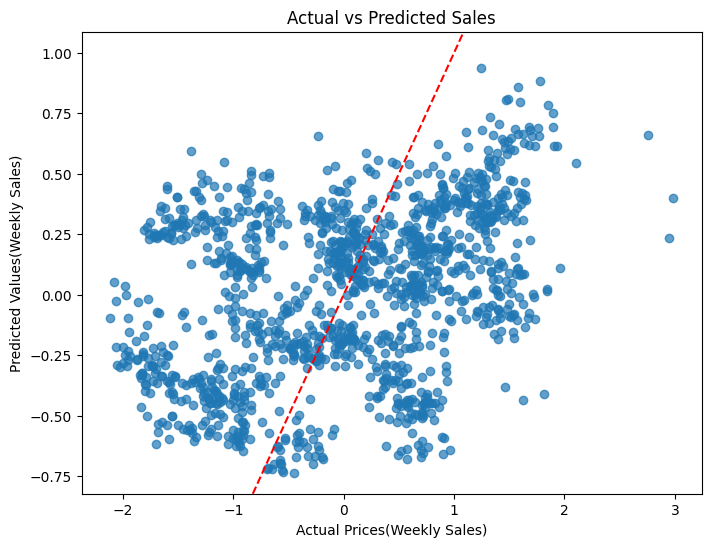

In [51]:
#scatter plot of actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Prices(Weekly Sales)")
plt.ylabel("Predicted Values(Weekly Sales)")
plt.title("Actual vs. Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [52]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5
print(f"Random  Forest R² Score: {r2:.4f}")
print(f"Random Forest RMSE: {rmse:.4f}")
#

Random  Forest R² Score: 0.9676
Random Forest RMSE: 0.1824


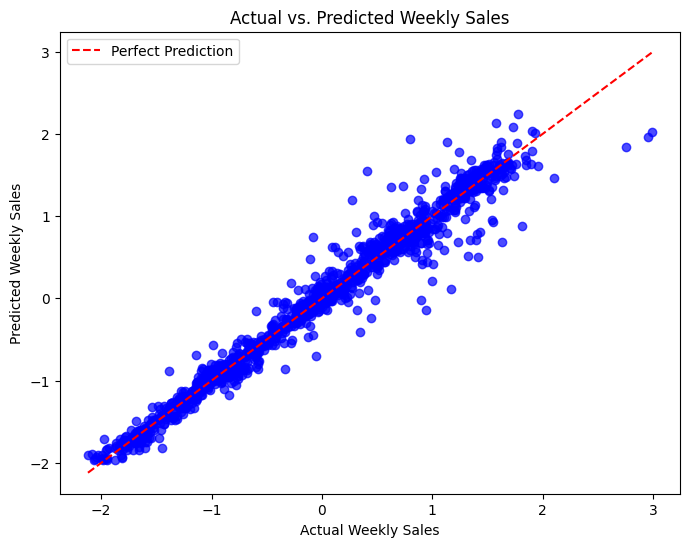

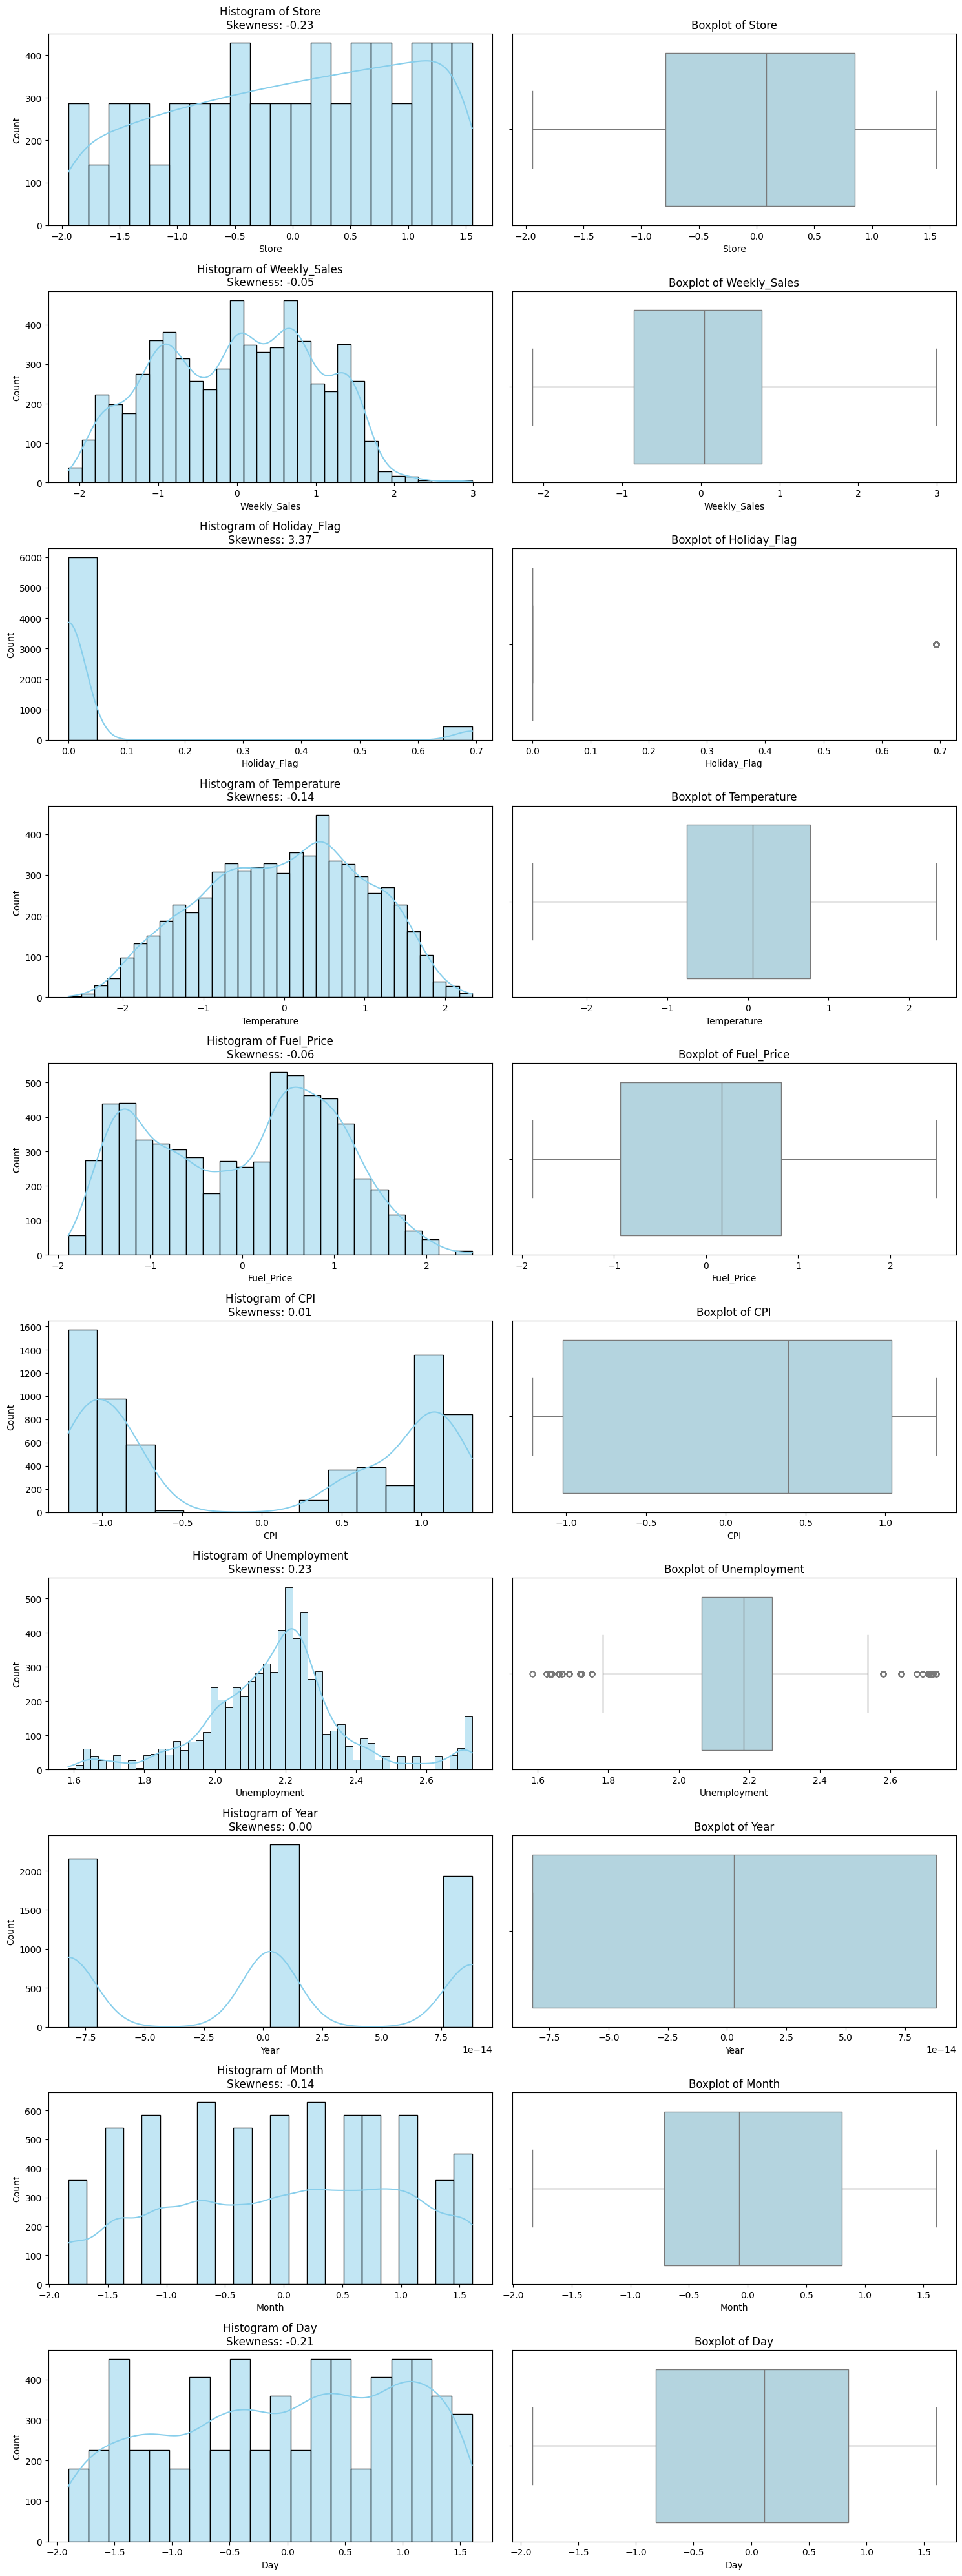

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# 1. Scatter plot of actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(x=y_test, y=y_pred, alpha=0.7, color='blue')
X = df[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year']]
y = df['Weekly_Sales']

# Dynamically draw the reference identity line based on data range
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Prediction")

plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs. Predicted Weekly Sales")  # Cleaned up title
plt.legend()
plt.show()


# 2. Calculate skewness for numeric columns only
skewness = df.skew(numeric_only=True)

# Filter out non-numeric columns (like Date) before plotting distributions
numeric_cols = df.select_dtypes(include=['number']).columns
num_cols = len(numeric_cols)

# Adjusted height based on actual numeric columns plotting
plt.figure(figsize=(15, num_cols * 4))

for i, col in enumerate(numeric_cols):
    # Histogram + KDE
    plt.subplot(num_cols, 2, 2 * i + 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Histogram of {col}\nSkewness: {skewness[col]:.2f}")

    # Boxplot
    plt.subplot(num_cols, 2, 2 * i + 2)
    sns.boxplot(x=df[col], color='lightblue')
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

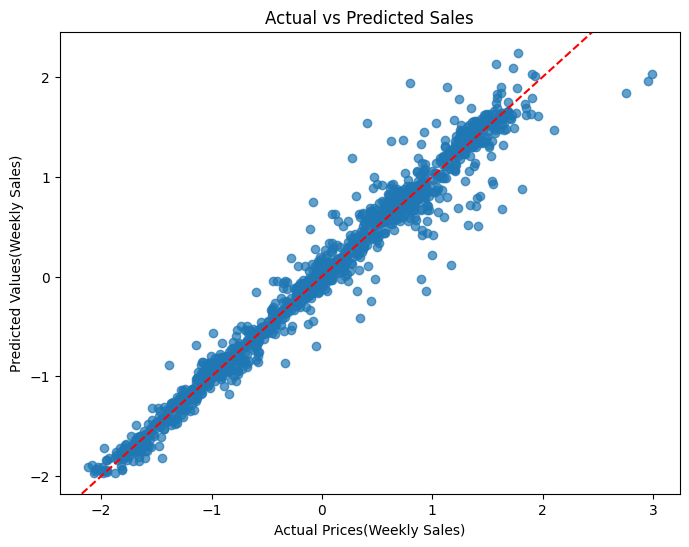

In [53]:
#scatter plot of actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Prices(Weekly Sales)")
plt.ylabel("Predicted Values(Weekly Sales)")
plt.title("Actual vs. Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()